# Laboratorio 3
## Lora Gallardo Rolando

## Descripción del Dataset

Este conjunto de datos contiene información detallada sobre **ventas de propiedades inmobiliarias en Melbourne, Australia**. Cada fila del dataset representa una transacción de compraventa de una vivienda, e incluye tanto las características físicas de la propiedad como los datos de la operación comercial.

La variable principal de interés es el **precio de venta (`Price`)**, lo que hace que este dataset sea ideal para construir modelos de regresión que predigan el valor de una propiedad en función de sus atributos (ubicación, tamaño, número de habitaciones, etc.).


## Diccionario de Variables

A continuación se describe cada una de las columnas del dataset:

| Columna | Significado |
| :--- | :--- |
| **Suburb** | Barrio o distrito donde se ubica la propiedad. |
| **Address** | Dirección postal completa. |
| **Rooms** | Número total de habitaciones (incluye dormitorios, salas, etc.). |
| **Type** | Tipo de vivienda: `h` (casa individual), `u` (unidad/departamento), `t` (casa adosada). |
| **Price** | Precio de venta en dólares australianos (variable objetivo). |
| **Method** | Método de venta: `S` (venta privada), `SP` (vendida antes de subasta), `PI` (pasada en subasta), `VB` (puja del vendedor), etc. |
| **SellerG** | Agente inmobiliario o empresa que gestionó la venta. |
| **Date** | Fecha de la transacción (formato día/mes/año). |
| **Distance** | Distancia en kilómetros desde la propiedad hasta el centro de Melbourne (CBD). |
| **Postcode** | Código postal de la zona. |
| **Bedroom2** | Número de dormitorios (la columna se llama "Bedroom2" por un error histórico). |
| **Bathroom** | Número de baños completos. |
| **Car** | Número de plazas de aparcamiento o cocheras. |
| **Landsize** | Superficie del terreno en metros cuadrados. |
| **BuildingArea** | Superficie construida en metros cuadrados. |
| **YearBuilt** | Año de construcción de la propiedad. |
| **CouncilArea** | Municipio o entidad de gobierno local que administra la zona. |
| **Lattitude** | Coordenada de latitud (ubicación Norte-Sur). |
| **Longtitude** | Coordenada de longitud (ubicación Este-Oeste). |
| **Regionname** | Región metropolitana a la que pertenece (ej. *Northern Metropolitan*). |
| **Propertycount** | Número total de propiedades en el suburbio (según registros censales). |

> **Nota**: Algunas columnas como `Landsize`, `BuildingArea` o `YearBuilt` presentan valores faltantes, lo cual es común en datasets del mundo real y deberá tratarse durante el análisis.

# Librerias Usadas

In [2]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [3]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np
import pandas as pd
# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D


# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

# Carga y visualizacion del Dataset

In [4]:
# Ruta al archivo
file_path = '/content/gdrive/MyDrive/Colab/datasets/laboratorio3/melb_data.csv'

# Cargar el CSV (pandas detecta automáticamente los encabezados)
df = pd.read_csv(file_path)

# Ver las primeras filas para confirmar
print(df.head())

       Suburb           Address  Rooms Type      Price Method SellerG  \
0  Abbotsford      85 Turner St      2    h  1480000.0      S  Biggin   
1  Abbotsford   25 Bloomburg St      2    h  1035000.0      S  Biggin   
2  Abbotsford      5 Charles St      3    h  1465000.0     SP  Biggin   
3  Abbotsford  40 Federation La      3    h   850000.0     PI  Biggin   
4  Abbotsford       55a Park St      4    h  1600000.0     VB  Nelson   

        Date  Distance  Postcode  ...  Bathroom  Car  Landsize  BuildingArea  \
0  3/12/2016       2.5    3067.0  ...       1.0  1.0     202.0           NaN   
1  4/02/2016       2.5    3067.0  ...       1.0  0.0     156.0          79.0   
2  4/03/2017       2.5    3067.0  ...       2.0  0.0     134.0         150.0   
3  4/03/2017       2.5    3067.0  ...       2.0  1.0      94.0           NaN   
4  4/06/2016       2.5    3067.0  ...       1.0  2.0     120.0         142.0   

   YearBuilt  CouncilArea Lattitude  Longtitude             Regionname  \
0     

#Preprocesamiento de los datos

In [5]:
# 4. Seleccionar columnas numéricas a usar
feature_cols = ['Rooms', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Distance']

print(f"Dimensiones originales del dataset: {df.shape}")

# 5. Eliminar filas donde el PRECIO (target) sea nulo
#    (si no tiene precio, no podemos usarlo para entrenar)
df = df.dropna(subset=['Price'])
print(f"Filas después de eliminar precios nulos: {len(df)}")

# 6. Imputar (rellenar) los valores nulos en las características con la MEDIANA
#    Aplicamos la mediana de cada columna a sus propios valores vacíos
for col in feature_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

# Verificar que ya no hay nulos en esas columnas
print("\nValores nulos restantes en las características:")
print(df[feature_cols].isnull().sum())

# 7. Crear X (características) e y (target)
X = df[feature_cols].values
y = df['Price'].values
# Escalar a miles de AUD (dividir entre 1000)
y = y / 1000
m = y.size
print(f"\nTamaño final de X: {X.shape}")
print(f"Tamaño final de y: {y.shape}")

# 8. Mostrar estadísticos básicos de las columnas imputadas
print("\nEstadísticos de las columnas numéricas (después de imputar):")
print(df[feature_cols].describe())

# 9. Mostrar algunas muestras
print("\nPrimeras 10 muestras (características y precio):")
for i in range(min(10, len(y))):
    print(f"Muestra {i+1}: {X[i]} -> ${y[i]:,.0f}")

Dimensiones originales del dataset: (13580, 21)
Filas después de eliminar precios nulos: 13580

Valores nulos restantes en las características:
Rooms           0
Bathroom        0
Car             0
Landsize        0
BuildingArea    0
YearBuilt       0
Distance        0
dtype: int64

Tamaño final de X: (13580, 7)
Tamaño final de y: (13580,)

Estadísticos de las columnas numéricas (después de imputar):
              Rooms      Bathroom           Car       Landsize  BuildingArea  \
count  13580.000000  13580.000000  13580.000000   13580.000000  13580.000000   
mean       2.937997      1.534242      1.611856     558.416127    139.633972   
std        0.955748      0.691712      0.960793    3990.669241    392.217403   
min        1.000000      0.000000      0.000000       0.000000      0.000000   
25%        2.000000      1.000000      1.000000     177.000000    122.000000   
50%        3.000000      1.000000      2.000000     440.000000    126.000000   
75%        3.000000      2.000000   

/tmp/ipykernel_772/2544585987.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


In [6]:
# Calcular correlación absoluta con el precio
correlations = df[feature_cols].corrwith(df['Price']).abs().sort_values(ascending=False)
best_feature = correlations.index[0]
print(f"La feature más importante (mayor correlación absoluta) es: '{best_feature}' con {correlations[best_feature]:.3f}")

La feature más importante (mayor correlación absoluta) es: 'Rooms' con 0.497


In [9]:
def plotData(x, y, xlabel='Característica', ylabel='Precio (miles)'):
    pyplot.figure(figsize=(8, 6))
    pyplot.plot(x, y, 'ro', ms=6, mec='k', alpha=0.6)
    pyplot.xlabel(xlabel)
    pyplot.ylabel(ylabel)
    pyplot.title(f'Relación entre {xlabel} y {ylabel}')
    pyplot.grid(True, linestyle='--', alpha=0.7)


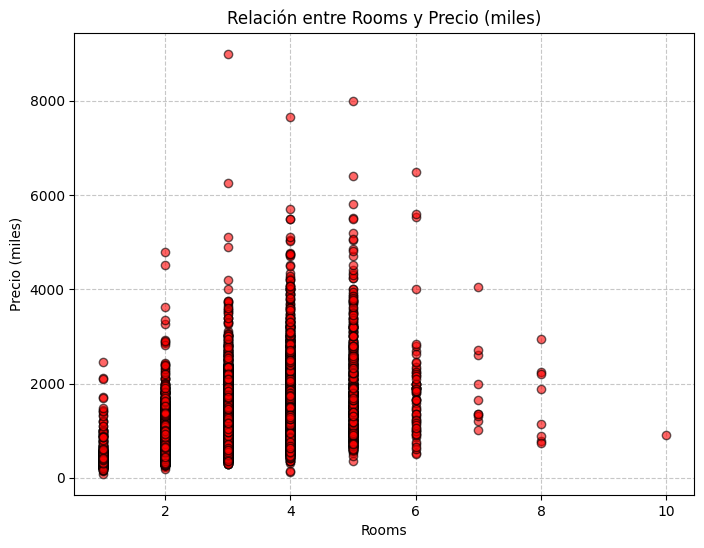

In [10]:
plotData(X[:, 0], y, xlabel='Rooms')

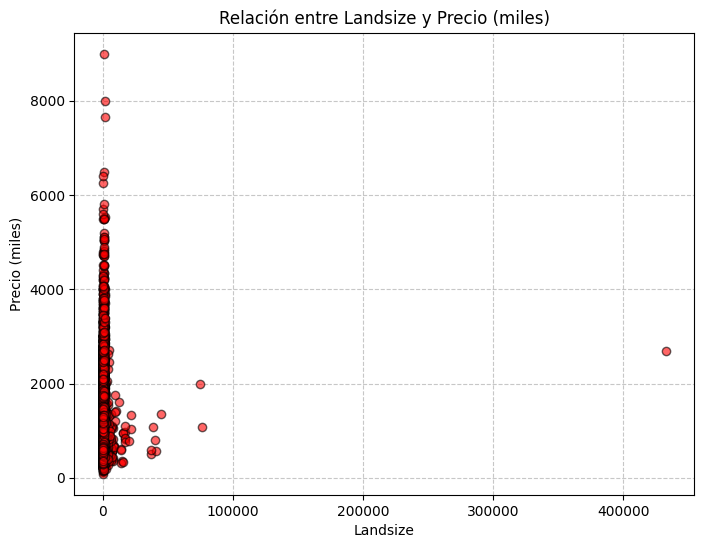

In [11]:
plotData(X[:, 3], y, xlabel='Landsize')

In [12]:
# 1. Calcular correlación con el precio para elegir la mejor feature
correlations = df[feature_cols].corrwith(df['Price']).abs().sort_values(ascending=False)
best_feature = correlations.index[0]
print(f"Feature seleccionada: '{best_feature}' (correlación = {correlations[best_feature]:.3f})")

# 2. Extraer SOLO esa feature en una matriz de una columna
X = df[[best_feature]].values
print(f"Dimensiones de X antes de transformar: {X.shape}")  # (m, 1)





Feature seleccionada: 'Rooms' (correlación = 0.497)
Dimensiones de X antes de transformar: (13580, 1)


In [13]:

X = np.concatenate([X, X * X], axis=1)
print(f"Dimensiones de X después de transformar: {X.shape}")  # (m, 2)

Dimensiones de X después de transformar: (13580, 2)


In [14]:
# 4. Ver las primeras 5 filas para comprobar
print("\nPrimeras 5 filas de X transformada:")
print(X[:5])


Primeras 5 filas de X transformada:
[[ 2  4]
 [ 2  4]
 [ 3  9]
 [ 3  9]
 [ 4 16]]


In [15]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [16]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

#print(X)
#print('Media calculada:', mu)
#print('Desviación estandar calculada:', sigma)
#print(X_norm)

In [17]:
print(X_norm)

[[-0.98146337 -0.90277781]
 [-0.98146337 -0.90277781]
 [ 0.06487613 -0.08876244]
 ...
 [ 0.06487613 -0.08876244]
 [ 1.11121563  1.05085907]
 [ 1.11121563  1.05085907]]


Despues de `featureNormalize` la funcion es provada, se añade el temino de interseccion a `X_norm`:

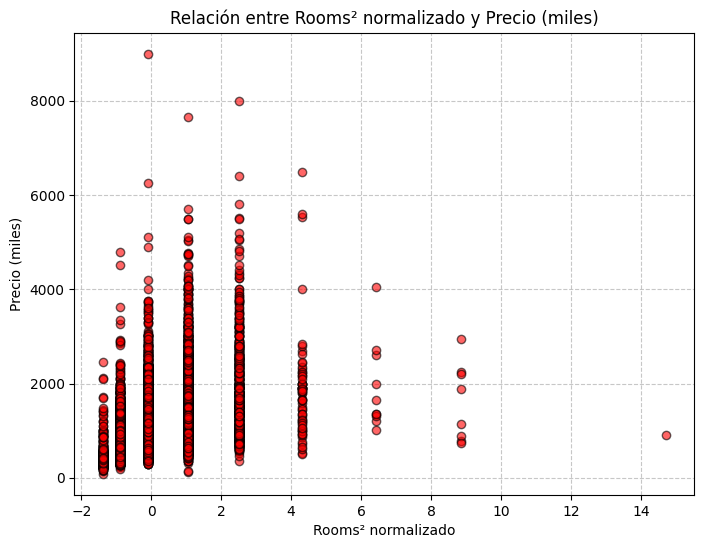

In [18]:
plotData(X_norm[:,1], y,
         xlabel='Rooms² normalizado'
         )

In [19]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
#X_norm = np.concatenate([X_norm, X_norm * X_norm], axis=1)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [20]:
print(X)

[[ 1.         -0.98146337 -0.90277781]
 [ 1.         -0.98146337 -0.90277781]
 [ 1.          0.06487613 -0.08876244]
 ...
 [ 1.          0.06487613 -0.08876244]
 [ 1.          1.11121563  1.05085907]
 [ 1.          1.11121563  1.05085907]]


In [21]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [22]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### 3.2.1 Seleccionando coheficientes de aprendizaje


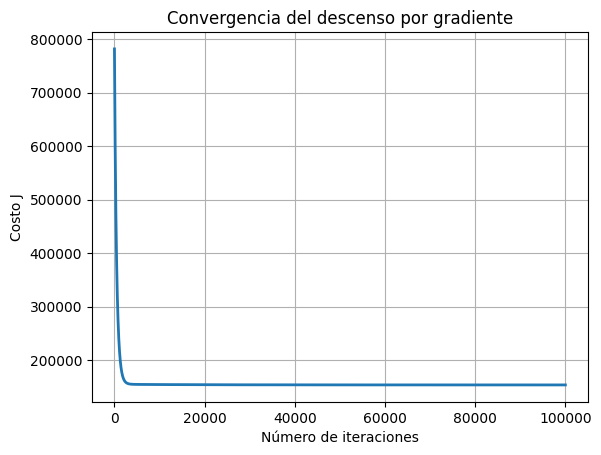

theta calculado por el descenso por el gradiente:
[1075.68407945  352.69954778  -36.60875263]

Precio estimado para una vivienda de 4 habitaciones:
$1,392 AUD


In [23]:
# Elegir alpha y num_iters (podemos probar estos valores primero)
alpha = 0.001
num_iters = 100000

# Inicializar theta (3 elementos porque X tiene 3 columnas)
theta = np.zeros(3)

# Ejecutar descenso por gradiente
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Graficar convergencia del costo
import matplotlib.pyplot as plt
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del descenso por gradiente')
plt.grid(True)
plt.show()

# Mostrar theta
print('theta calculado por el descenso por el gradiente:')
print(theta)


# Elegir un número de habitaciones para predecir (ej. 4 habitaciones)
rooms = 4

# Crear vector de características en escala original: [1, rooms, rooms^2]
X_pred = np.array([1, rooms, rooms**2])

# Normalizar las características (posiciones 1 y 2) con mu y sigma
X_pred[1:3] = (X_pred[1:3] - mu) / sigma

# Calcular precio predicho
price_pred = np.dot(X_pred, theta)

# Mostrar resultado
print(f'\nPrecio estimado para una vivienda de {rooms} habitaciones:')
print(f'${price_pred:,.0f} AUD')

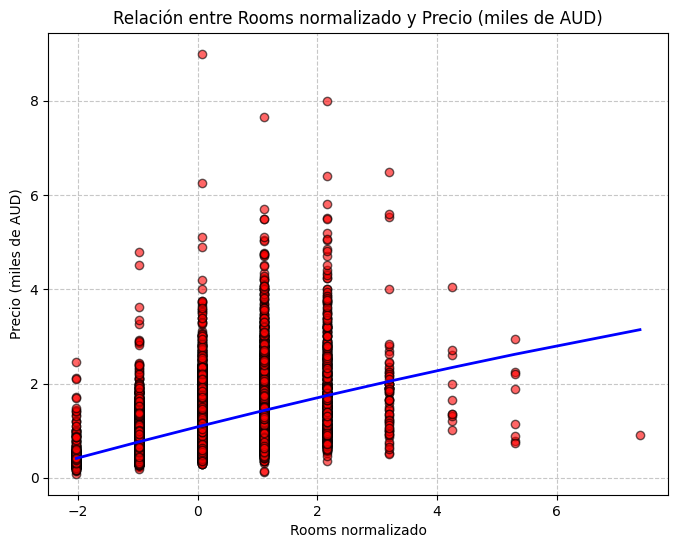

In [24]:
# Ordenar para que la curva sea suave
idx = np.argsort(X[:, 1])
x_sorted = X[:, 1][idx]
y_pred_sorted = np.dot(X, theta)[idx]

plotData(X[:, 1], y/1000, xlabel='Rooms normalizado', ylabel='Precio (miles de AUD)')
plt.plot(x_sorted, y_pred_sorted/1000, '-', color='blue', linewidth=2)
plt.show()

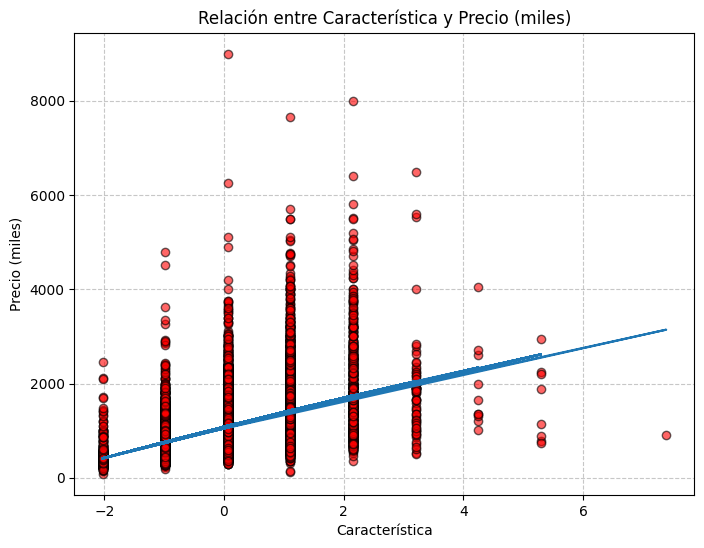

In [25]:
plotData(X[:, 1], y)
pyplot.plot(X[:, 1], np.dot(X, theta), '-')


#Ecuacion de la Normal



In [26]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [27]:
# 2. Calcular theta
theta_norm = normalEqn(X, y)
print('Theta calculado con la ecuación normal:')
print(theta_norm)

Theta calculado con la ecuación normal:
[1075.68407946  363.15949579  -47.06870064]


In [28]:
# 3. Predicción para 4 habitaciones
rooms = 4
X_input = np.array([rooms, rooms**2])
X_input_norm = (X_input - mu) / sigma
X_input_final = np.concatenate([np.array([1]), X_input_norm])
price_pred = np.dot(X_input_final, theta_norm)
print(f'Precio estimado para una casa con {rooms} habitaciones: ${price_pred:,.0f} AUD')

Precio estimado para una casa con 4 habitaciones: $1,430 AUD


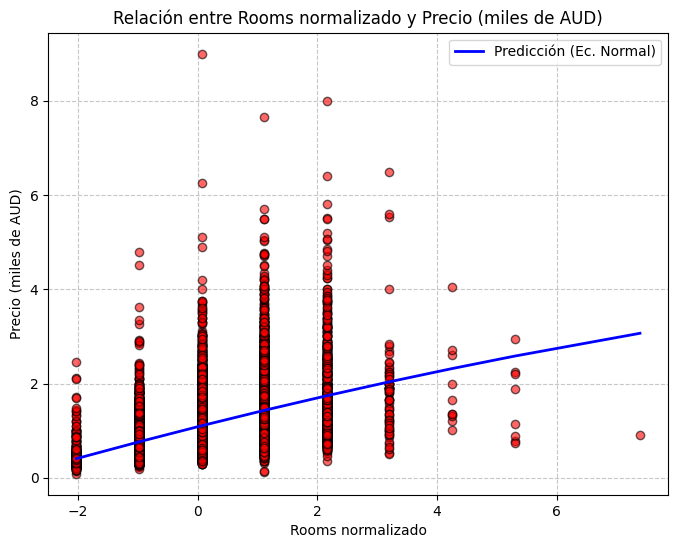

In [29]:
# 4. Visualización
idx = np.argsort(X[:, 1])
x_sorted = X[:, 1][idx]
y_pred_sorted = np.dot(X, theta_norm)[idx]

plotData(X[:, 1], y/1000, xlabel='Rooms normalizado', ylabel='Precio (miles de AUD)')
plt.plot(x_sorted, y_pred_sorted/1000, '-', color='blue', linewidth=2, label='Predicción (Ec. Normal)')
plt.legend()
plt.show()

#Multivariable

/tmp/ipykernel_772/1875372581.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_multi[col].fillna(median_val, inplace=True)


Dimensiones de X_multi_raw: (13580, 7)
Total de ejemplos para multivariable: 13580
Dimensiones finales de X_multi: (13580, 8)

Theta calculado con descenso por gradiente (Multivariable):
[1075683.77433089  231425.00795848  180448.63851699   58469.32579876
   14128.82629479   15909.88126513 -143457.86764527 -183715.95286031]

Theta calculado con ecuación normal (Multivariable):
[1075684.07945508  231699.57801539  180218.80932765   58437.19994833
   14134.01607749   15914.64497262 -143365.05985668 -183809.86197477]


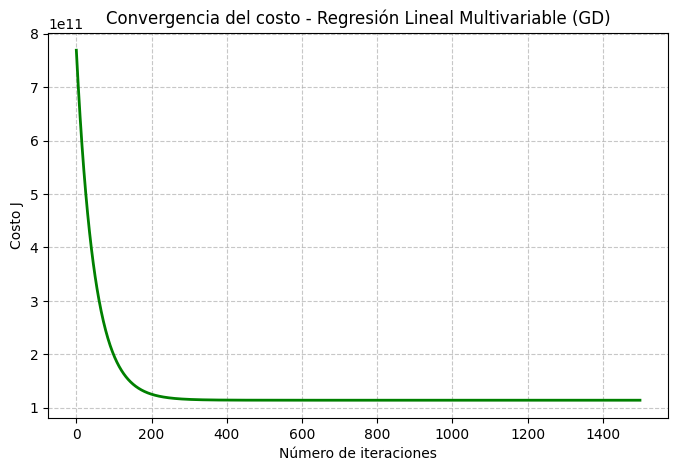


Comparación de theta (GD vs Normal Eq):
Diferencia absoluta: [  0.30512419 274.5700569  229.82918934  32.12585043   5.18978269
   4.76370749  92.80778858  93.90911446]


In [30]:

# 1. PREPARAR DATOS PARA REGRESIÓN LINEAL MULTIVARIABLE


# Definir las columnas numéricas que usaremos
feature_cols = ['Rooms', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Distance']

# Crear un DataFrame temporal con las columnas seleccionadas + el precio
df_multi = df[feature_cols + ['Price']].copy()

# Imputar valores nulos en las características con la mediana
for col in feature_cols:
    median_val = df_multi[col].median()
    df_multi[col].fillna(median_val, inplace=True)

# Eliminar filas donde el precio sea nulo (si las hubiera)
df_multi.dropna(subset=['Price'], inplace=True)

# Extraer X (características) e y (precio)
X_multi_raw = df_multi[feature_cols].values
y_multi = df_multi['Price'].values
m_multi = y_multi.size

print(f"Dimensiones de X_multi_raw: {X_multi_raw.shape}")
print(f"Total de ejemplos para multivariable: {m_multi}")


# 2. NORMALIZAR CARACTERÍSTICAS


X_multi_norm, mu_multi, sigma_multi = featureNormalize(X_multi_raw)


# 3. AÑADIR COLUMNA DE UNOS (INTERCEPTO)


X_multi = np.concatenate([np.ones((m_multi, 1)), X_multi_norm], axis=1)

print(f"Dimensiones finales de X_multi: {X_multi.shape}")  # Debe ser (m, 8)


# 4. ENTRENAR CON DESCIENSO POR GRADIENTE


# Elegir alpha y número de iteraciones
alpha_multi = 0.01
num_iters_multi = 1500

# Inicializar theta (8 elementos: 1 intercepto + 7 características)
theta_multi = np.zeros(X_multi.shape[1])

# Ejecutar gradiente descendente
theta_multi, J_history_multi = gradientDescentMulti(X_multi, y_multi, theta_multi, alpha_multi, num_iters_multi)

print("\nTheta calculado con descenso por gradiente (Multivariable):")
print(theta_multi)


# 5. ENTRENAR CON ECUACIÓN NORMAL


theta_multi_norm = normalEqn(X_multi, y_multi)

print("\nTheta calculado con ecuación normal (Multivariable):")
print(theta_multi_norm)


# 6. GRAFICAR CONVERGENCIA DEL COSTO (GRADIENTE)


plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(J_history_multi)), J_history_multi, lw=2, color='green')
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del costo - Regresión Lineal Multivariable (GD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# 7. COMPARAR RESULTADOS DE AMBOS MÉTODOS


print("\nComparación de theta (GD vs Normal Eq):")
print("Diferencia absoluta:", np.abs(theta_multi - theta_multi_norm))

In [35]:

# PREDICCIONES CON MODELOS YA ENTRENADOS (SIN REENTRENAR)


# 1. Dividir datos en entrenamiento (70%) y prueba (30%)
from sklearn.model_selection import train_test_split

# Usamos los datos originales (ya limpios) para crear las particiones
X_raw = df[feature_cols].values
y_raw = df['Price'].values   # Precio en miles (igual que usamos en entrenamiento)

# Dividir (usamos una semilla fija para reproducibilidad)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.3, random_state=42
)

print(f"Entrenamiento: {X_train_raw.shape[0]} muestras")
print(f"Prueba: {X_test_raw.shape[0]} muestras")

# 2. Preparar datos de prueba para cada modelo

# --- Para el modelo polinómico (Rooms) ---
# Extraer solo la columna de Rooms
X_test_poly = X_test_raw[:, 0].reshape(-1, 1)

# Transformación polinómica: [Rooms, Rooms²]
X_test_poly = np.concatenate([X_test_poly, X_test_poly**2], axis=1)

# Normalizar con los parámetros del entrenamiento (usamos mu y sigma ya calculados)
X_test_poly_norm = (X_test_poly - mu) / sigma

# Añadir intercepto
X_test_poly_final = np.concatenate([np.ones((X_test_poly_norm.shape[0], 1)), X_test_poly_norm], axis=1)

# --- Para el modelo multivariable (todas las features) ---
# Normalizar con los parámetros del entrenamiento (usamos mu_multi y sigma_multi)
X_test_multi_norm = (X_test_raw - mu_multi) / sigma_multi

# Añadir intercepto
X_test_multi_final = np.concatenate([np.ones((X_test_multi_norm.shape[0], 1)), X_test_multi_norm], axis=1)

# 3. Generar predicciones con cada modelo (sobre prueba)
y_pred_poly_gd = np.dot(X_test_poly_final, theta)           # Polinómico GD
y_pred_poly_norm = np.dot(X_test_poly_final, theta_norm)    # Polinómico Normal Eq
y_pred_multi_gd = np.dot(X_test_multi_final, theta_multi)   # Multivariable GD
y_pred_multi_norm = np.dot(X_test_multi_final, theta_multi_norm)  # Multivariable Normal Eq

# 4. Mostrar las primeras 100 predicciones
print("\n" + "="*50)
print("PRIMERAS 100 PREDICCIONES (Multivariable - Normal Eq)")
print("="*50)
print(f"{'Real':>10} {'Predicho':>10} {'Error':>10}")
print("-"*35)

for i in range(min(100, len(y_test))):
    real = y_test[i]
    pred = y_pred_multi_norm[i]
    error = real - pred
    print(f"{real:>10,.0f} {pred:>10,.0f} {error:>10,.0f}")

# 5. Métricas de error para cada modelo (opcional, pero útil)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


print("\n" + "="*50)
print("MÉTRICAS DE ERROR SOBRE PRUEBA")
print("="*50)

modelos = [
    ("Polinómico (GD)", y_pred_poly_gd),
    ("Polinómico (Normal Eq)", y_pred_poly_norm),
    ("Multivariable (GD)", y_pred_multi_gd),
    ("Multivariable (Normal Eq)", y_pred_multi_norm)
]

for nombre, y_pred in modelos:
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"\n{nombre}:")
    print(f"  MAE:  ${mae:,.0f} miles")
    print(f"  RMSE: ${rmse:,.0f} miles")
    print(f"  R²:   {r2:.4f}")



Entrenamiento: 9506 muestras
Prueba: 4074 muestras

PRIMERAS 100 PREDICCIONES (Multivariable - Normal Eq)
      Real   Predicho      Error
-----------------------------------
 2,600,000  1,245,870  1,354,130
   620,000    730,375   -110,375
 1,000,000  1,167,067   -167,067
   430,000    965,916   -535,916
   392,250    746,054   -353,804
   700,000    987,566   -287,566
   439,000    559,345   -120,345
 2,236,000  1,813,869    422,131
   671,000    764,907    -93,907
 1,870,000  1,042,495    827,505
 2,525,000  1,513,480  1,011,520
   710,000    919,034   -209,034
 1,330,000    802,429    527,571
   642,500    941,497   -298,997
   731,000    392,676    338,324
   860,000  1,015,446   -155,446
   429,000    638,643   -209,643
   790,500  1,054,356   -263,856
 2,350,000  1,917,266    432,734
   330,000    230,111     99,889
   820,000    783,901     36,099
   742,000    731,537     10,463
   915,000  1,453,977   -538,977
 1,562,500  1,226,339    336,161
 1,630,000  1,017,063    612,937
